In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")


In [3]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [4]:
df['Health_Impacts'] = df['Health_Impacts'].replace({None: "No health impacts"})


In [5]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [6]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [7]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [8]:
df.shape

(9712, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     9712 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [10]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [11]:
df['Age'].value_counts()

Age
17    919
8     912
13    910
14    896
9     885
10    877
16    876
12    867
11    866
15    864
18    840
Name: count, dtype: int64

<Axes: >

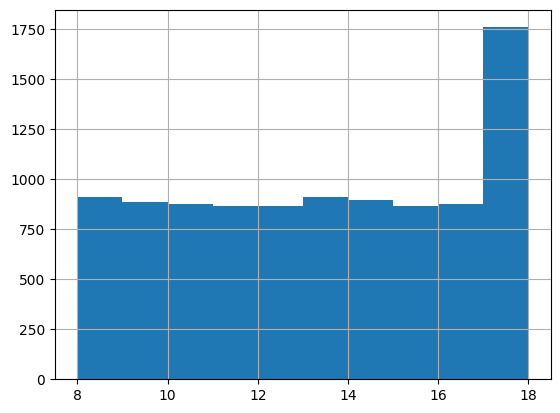

In [12]:
df['Age'].hist()

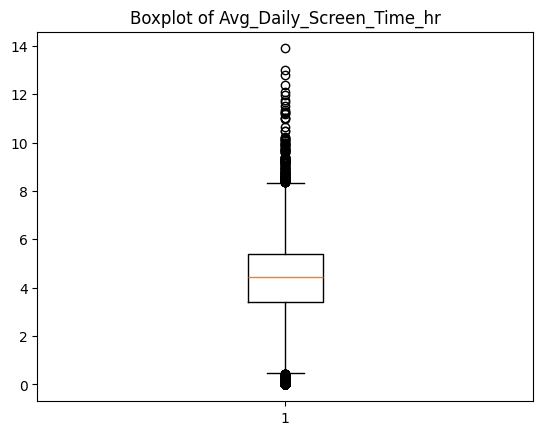

In [13]:
plt.boxplot(df['Avg_Daily_Screen_Time_hr'].dropna())
plt.title("Boxplot of Avg_Daily_Screen_Time_hr")
plt.show()


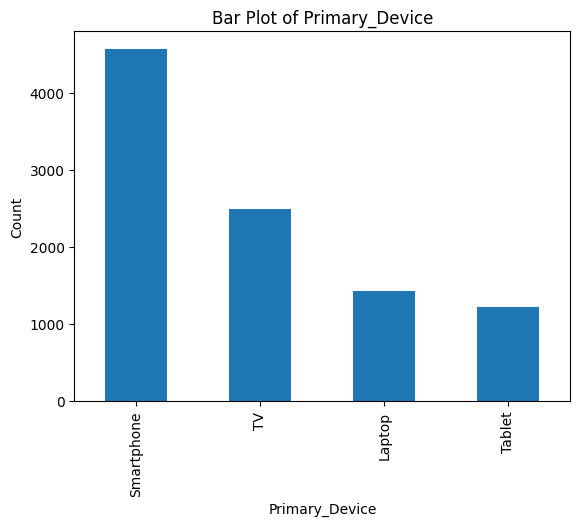

In [14]:
df['Primary_Device'].value_counts().plot(kind='bar')
plt.title("Bar Plot of Primary_Device")
plt.xlabel("Primary_Device")
plt.ylabel("Count")
plt.show()


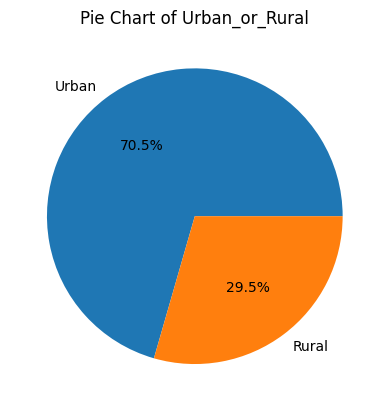

In [15]:
df['Urban_or_Rural'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pie Chart of Urban_or_Rural")
plt.ylabel("")
plt.show()


In [16]:
#week 2 EDA 
df.duplicated().sum()
df = df.drop_duplicates()

In [17]:
df.shape

(9668, 8)

In [18]:
df['Age'].describe()
df[df['Age'] < 0]
df[df['Age'] > 18]   
# output has 0 columns means age column is within range


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural


In [19]:
df['Gender'].value_counts()
df['Gender'].unique()
#I checked categorical consistency

array(['Male', 'Female'], dtype=object)

In [20]:

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(col, "Outliers:", df[(df[col] < lower) | (df[col] > upper)].shape[0])


Age Outliers: 0
Avg_Daily_Screen_Time_hr Outliers: 428
Educational_to_Recreational_Ratio Outliers: 0


In [21]:
df['Avg_Daily_Screen_Time_hr'].describe()
#I checked range validity

count    9668.000000
mean        4.367780
std         1.703002
min         0.000000
25%         3.427500
50%         4.440000
75%         5.380000
max        13.890000
Name: Avg_Daily_Screen_Time_hr, dtype: float64

In [22]:
df['Primary_Device'].value_counts()
#Looked for:Spelling differences and Extra spaces

Primary_Device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

In [23]:
df['Exceeded_Recommended_Limit'].value_counts()
#I verified binary consistency.

Exceeded_Recommended_Limit
True     8292
False    1376
Name: count, dtype: int64

In [24]:
df['Educational_to_Recreational_Ratio'].describe()
df[df['Educational_to_Recreational_Ratio'] < 0]
#Looked for:Negative values and Extreme values

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural


In [25]:
df['Urban_or_Rural'].value_counts()
#I checked categorical consistency

Urban_or_Rural
Urban    6810
Rural    2858
Name: count, dtype: int64

In [26]:
bins = [0, 5, 12, 15, 18]
labels = ['Toddler', 'Child', 'Early Teen', 'Late Teen']

df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
#Create age groups.

In [27]:
df['Age_Band'].value_counts()

Age_Band
Child         4368
Early Teen    2669
Late Teen     2631
Toddler          0
Name: count, dtype: int64

In [28]:
#Since the dataset does not contain date or day information, weekday/weekend flag cannot be created.

In [29]:
#Device Share (Screen Time by Device)
device_share = df['Primary_Device'].value_counts(normalize=True) * 100
print(device_share)

Primary_Device
Smartphone    46.959040
TV            25.630947
Laptop        14.801407
Tablet        12.608606
Name: proportion, dtype: float64


In [30]:
#Activity Share (Educational vs Recreational)
df['Usage_Type'] = df['Educational_to_Recreational_Ratio'].apply(
    lambda x: 'Educational' if x > 0.5 else 'Recreational'
)

In [31]:
df['Usage_Type'].value_counts()

Usage_Type
Recreational    8395
Educational     1273
Name: count, dtype: int64

In [32]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural', 'Age_Band', 'Usage_Type'],
      dtype='object')

In [33]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Usage_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,Recreational
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban,Early Teen,Recreational
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,Recreational
...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Late Teen,Recreational
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Late Teen,Recreational
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Late Teen,Recreational
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Late Teen,Recreational


In [34]:
portable_devices = ['Smartphone', 'Tablet', 'Laptop']

df['Device_Type'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in portable_devices else 'Non-Portable'
)

In [35]:
df


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Usage_Type,Device_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational,Portable
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,Recreational,Portable
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban,Early Teen,Recreational,Portable
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,Recreational,Portable
...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Late Teen,Recreational,Portable
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Late Teen,Recreational,Portable
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Late Teen,Recreational,Portable
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable


In [36]:
mean_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()
print(mean_screen_time)

4.367780306164667


In [37]:
df['Day_Type'] = df['Avg_Daily_Screen_Time_hr'].apply(
    lambda x: 'Weekend' if x > mean_screen_time else 'Weekday'
)

In [38]:
df['Day_Type'].value_counts()

Day_Type
Weekend    5022
Weekday    4646
Name: count, dtype: int64

In [39]:
df


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Usage_Type,Device_Type,Day_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational,Portable,Weekday
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,Recreational,Portable,Weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekday
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban,Early Teen,Recreational,Portable,Weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,Recreational,Portable,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Late Teen,Recreational,Portable,Weekday
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Late Teen,Recreational,Portable,Weekend
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Late Teen,Recreational,Portable,Weekend
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekend


In [40]:
df['Avg_Daily_Screen_Time_hr'].value_counts()

Avg_Daily_Screen_Time_hr
0.00     194
4.93      40
4.96      39
4.32      39
4.03      39
        ... 
9.68       1
8.22       1
8.06       1
10.07      1
7.47       1
Name: count, Length: 899, dtype: int64

In [41]:
df['Screen_Time_Level'] = pd.cut(
    df['Avg_Daily_Screen_Time_hr'],
    bins=[-0.01,2,4,6,14],
    labels=['Low','Moderate','High','Very High']
)

In [42]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Usage_Type,Device_Type,Day_Type,Screen_Time_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational,Portable,Weekday,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,Recreational,Portable,Weekend,High
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekday,Moderate
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban,Early Teen,Recreational,Portable,Weekday,Low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,Recreational,Portable,Weekend,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Late Teen,Recreational,Portable,Weekday,Moderate
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Late Teen,Recreational,Portable,Weekend,High
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Late Teen,Recreational,Portable,Weekend,High
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekend,High


In [43]:
median_ratio = df['Educational_to_Recreational_Ratio'].median()
df['Engagement_Risk_Level'] = df.apply(
    lambda row: 'High Risk' if row['Avg_Daily_Screen_Time_hr'] > 6 and row['Educational_to_Recreational_Ratio'] < median_ratio
    else 'Moderate Risk' if row['Avg_Daily_Screen_Time_hr'] > 4
    else 'Low Risk',
    axis=1
)

In [44]:
df


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Usage_Type,Device_Type,Day_Type,Screen_Time_Level,Engagement_Risk_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational,Portable,Weekday,Moderate,Low Risk
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,Recreational,Portable,Weekend,High,Moderate Risk
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekday,Moderate,Low Risk
3,15,Female,1.21,Laptop,False,0.39,No health impacts,Urban,Early Teen,Recreational,Portable,Weekday,Low,Low Risk
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,Recreational,Portable,Weekend,High,Moderate Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Late Teen,Recreational,Portable,Weekday,Moderate,Low Risk
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Late Teen,Recreational,Portable,Weekend,High,Moderate Risk
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Late Teen,Recreational,Portable,Weekend,High,Moderate Risk
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Late Teen,Recreational,Non-Portable,Weekend,High,Moderate Risk


In [45]:
df.to_csv("Processed_Kids_Screen_Time.csv", index=False)

In [46]:
df = pd.read_csv("Processed_Kids_Screen_Time.csv")

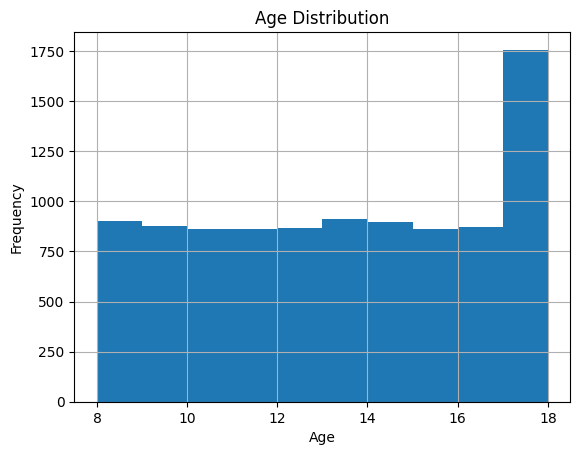

In [47]:
#UNIVARIATE ANALYSIS
#1. Numerical Variables
#Histogram – Age
import matplotlib.pyplot as plt

df['Age'].hist()
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

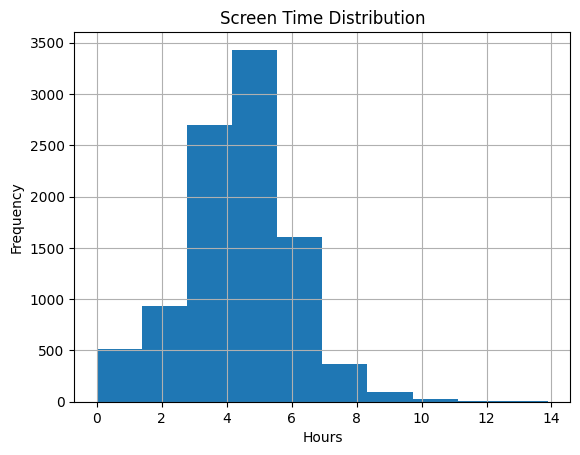

In [48]:
#Histogram – Screen Time
df['Avg_Daily_Screen_Time_hr'].hist()
plt.title('Screen Time Distribution')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

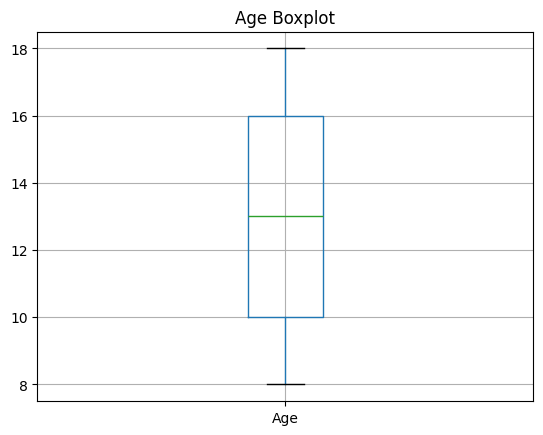

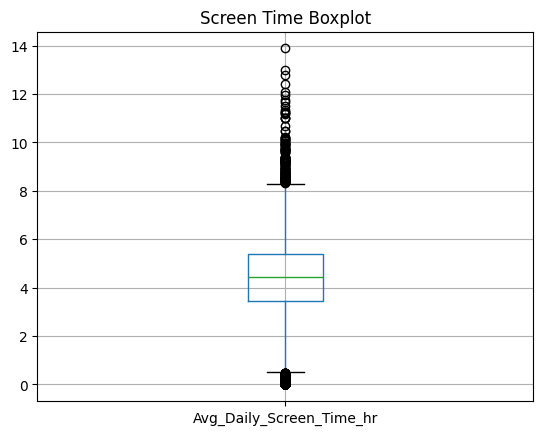

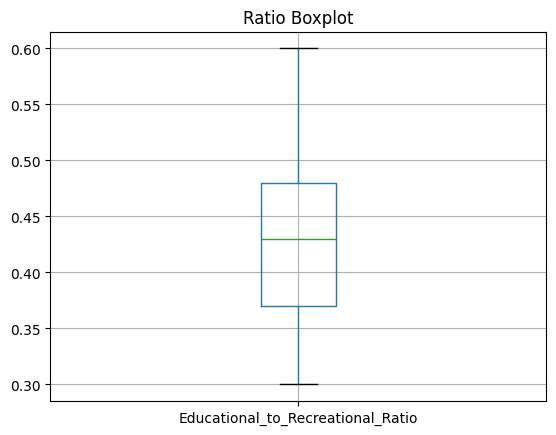

In [49]:
#Boxplot 
df.boxplot(column='Age')
plt.title('Age Boxplot')
plt.show()

df.boxplot(column='Avg_Daily_Screen_Time_hr')
plt.title('Screen Time Boxplot')
plt.show()

df.boxplot(column='Educational_to_Recreational_Ratio')
plt.title('Ratio Boxplot')
plt.show()

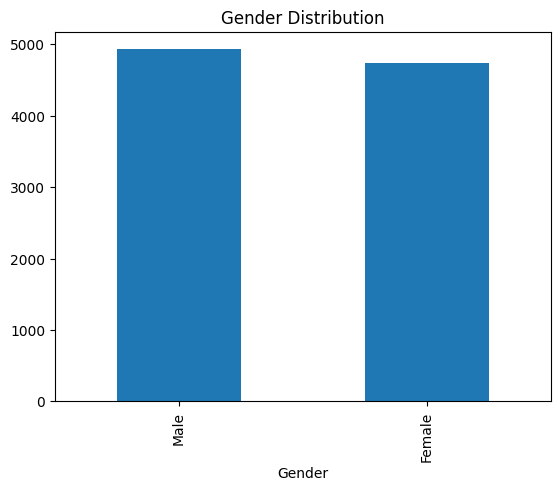

In [50]:
#2. Categorical Variables
#Gender Distribution
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()


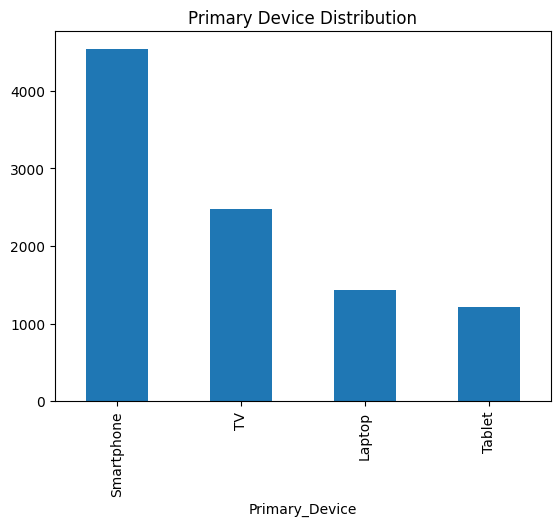

In [51]:
#Primary Device
df['Primary_Device'].value_counts().plot(kind='bar')
plt.title('Primary Device Distribution')
plt.show()


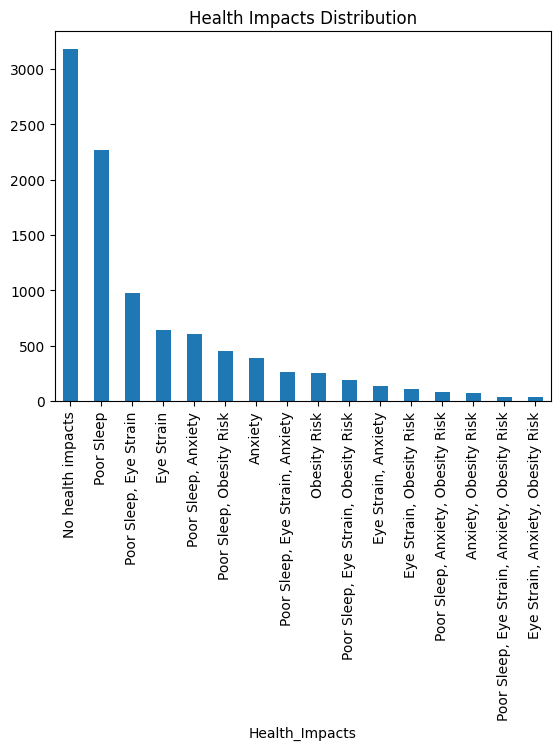

In [52]:
#Health Impacts
df['Health_Impacts'].value_counts().plot(kind='bar')
plt.title('Health Impacts Distribution')
plt.show()


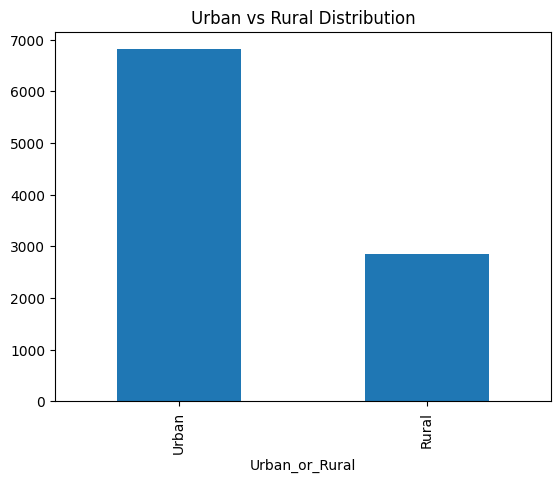

In [53]:
#Urban vs Rural
df['Urban_or_Rural'].value_counts().plot(kind='bar')
plt.title('Urban vs Rural Distribution')
plt.show()

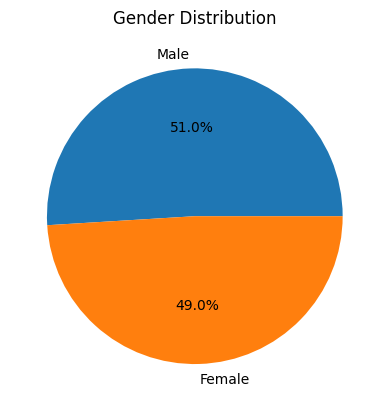

In [54]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

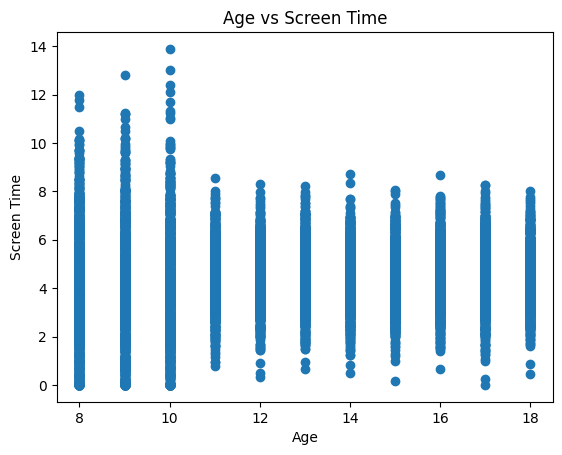

In [55]:
#BIVARIATE ANALYSIS
#1. Numerical vs Numerical
#Age vs Screen Time (Scatter)
plt.scatter(df['Age'], df['Avg_Daily_Screen_Time_hr'])
plt.xlabel('Age')
plt.ylabel('Screen Time')
plt.title('Age vs Screen Time')
plt.show()

In [56]:
df[['Age',
    'Avg_Daily_Screen_Time_hr',
    'Educational_to_Recreational_Ratio']].corr()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Age,1.000000,0.108873,-0.488017
Avg_Daily_Screen_Time_hr,0.108873,1.000000,-0.081445
Educational_to_Recreational_Ratio,-0.488017,-0.081445,1.000000


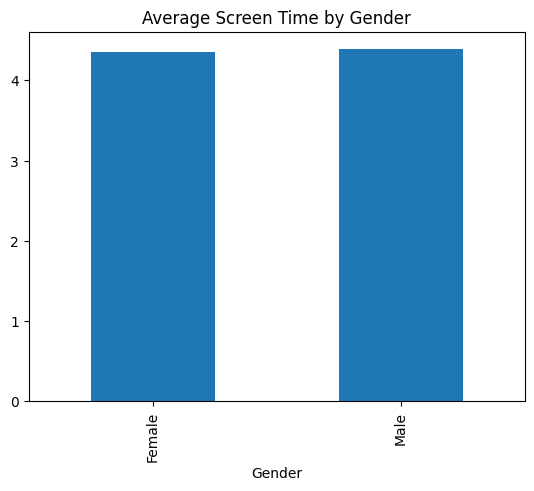

In [57]:
#2. Categorical vs Numerical
#Gender vs Screen Time
df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()
df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean().plot(kind='bar')
plt.title('Average Screen Time by Gender')
plt.show()

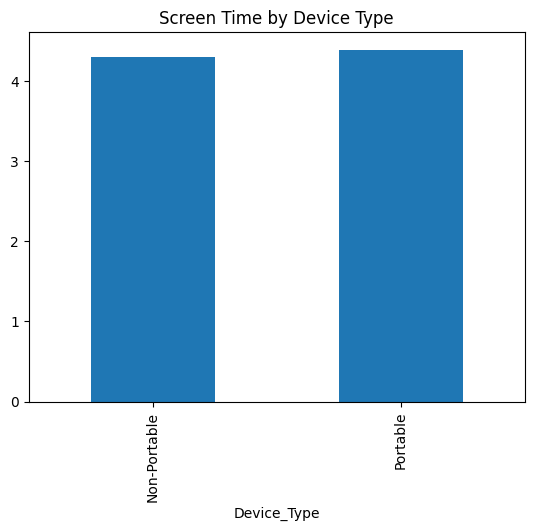

In [58]:
#Device Type vs Screen Time
df.groupby('Device_Type')['Avg_Daily_Screen_Time_hr'].mean().plot(kind='bar')
plt.title('Screen Time by Device Type')
plt.show()

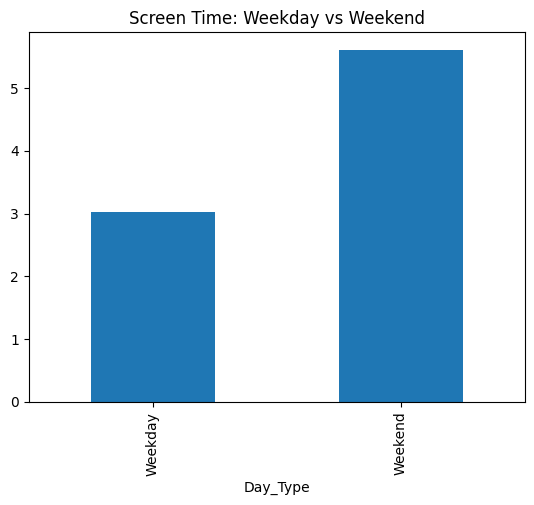

In [59]:
#Day Type vs Screen Time
df.groupby('Day_Type')['Avg_Daily_Screen_Time_hr'].mean().plot(kind='bar')
plt.title('Screen Time: Weekday vs Weekend')
plt.show()

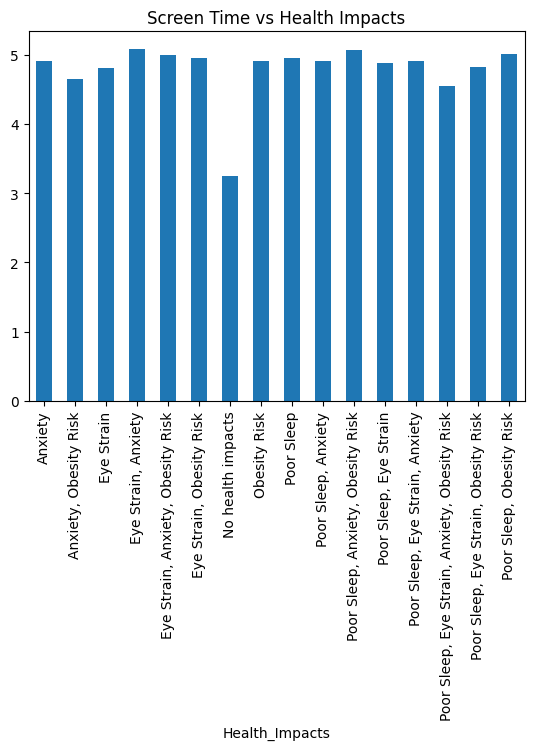

In [60]:
#Health Impacts vs Screen Time
df.groupby('Health_Impacts')['Avg_Daily_Screen_Time_hr'].mean().plot(kind='bar')
plt.title('Screen Time vs Health Impacts')
plt.show()

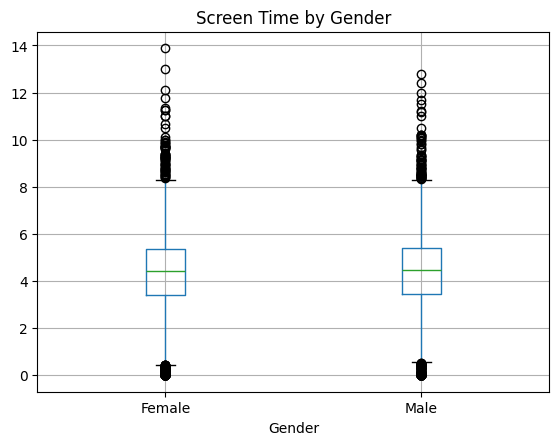

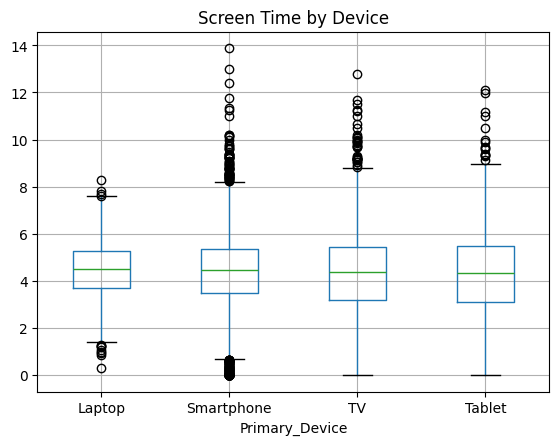

In [61]:
#Boxplot
df.boxplot(column='Avg_Daily_Screen_Time_hr', by='Gender')
plt.title('Screen Time by Gender')
plt.suptitle('')
plt.show()

df.boxplot(column='Avg_Daily_Screen_Time_hr', by='Primary_Device')
plt.title('Screen Time by Device')
plt.suptitle('')
plt.show()

In [62]:
#3. Categorical vs Categorical
#Gender vs Device
pd.crosstab(df['Gender'], df['Primary_Device'])

Primary_Device,Laptop,Smartphone,TV,Tablet
Gender,,,,
Female,739,2201,1213,587
Male,692,2339,1265,632


In [63]:
#Exceeded Limit vs Health Impact
pd.crosstab(df['Exceeded_Recommended_Limit'], df['Health_Impacts'])

Health_Impacts,Anxiety,"Anxiety, Obesity Risk",Eye Strain,"Eye Strain, Anxiety","Eye Strain, Anxiety, Obesity Risk","Eye Strain, Obesity Risk",No health impacts,Obesity Risk,Poor Sleep,"Poor Sleep, Anxiety","Poor Sleep, Anxiety, Obesity Risk","Poor Sleep, Eye Strain","Poor Sleep, Eye Strain, Anxiety","Poor Sleep, Eye Strain, Anxiety, Obesity Risk","Poor Sleep, Eye Strain, Obesity Risk","Poor Sleep, Obesity Risk"
Exceeded_Recommended_Limit,,,,,,,,,,,,,,,,
False,0,0,0,0,0,0,1376,0,0,0,0,0,0,0,0,0
True,385,69,644,135,35,106,1804,252,2264,607,78,978,258,37,188,452


In [64]:
#Urban/Rural vs Health Impacts
pd.crosstab(df['Urban_or_Rural'], df['Health_Impacts'])

Health_Impacts,Anxiety,"Anxiety, Obesity Risk",Eye Strain,"Eye Strain, Anxiety","Eye Strain, Anxiety, Obesity Risk","Eye Strain, Obesity Risk",No health impacts,Obesity Risk,Poor Sleep,"Poor Sleep, Anxiety","Poor Sleep, Anxiety, Obesity Risk","Poor Sleep, Eye Strain","Poor Sleep, Eye Strain, Anxiety","Poor Sleep, Eye Strain, Anxiety, Obesity Risk","Poor Sleep, Eye Strain, Obesity Risk","Poor Sleep, Obesity Risk"
Urban_or_Rural,,,,,,,,,,,,,,,,
Rural,117,20,189,30,14,25,960,75,654,192,17,286,79,14,57,129
Urban,268,49,455,105,21,81,2220,177,1610,415,61,692,179,23,131,323


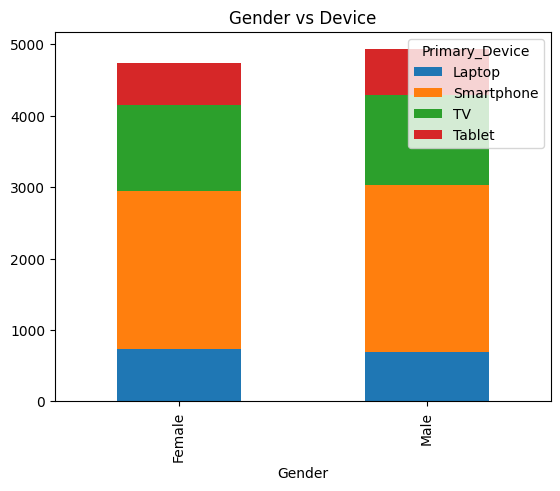

In [65]:
#Crosstab + Stacked Bar
ct = pd.crosstab(df['Gender'], df['Primary_Device'])
ct.plot(kind='bar', stacked=True)
plt.title('Gender vs Device')
plt.show()

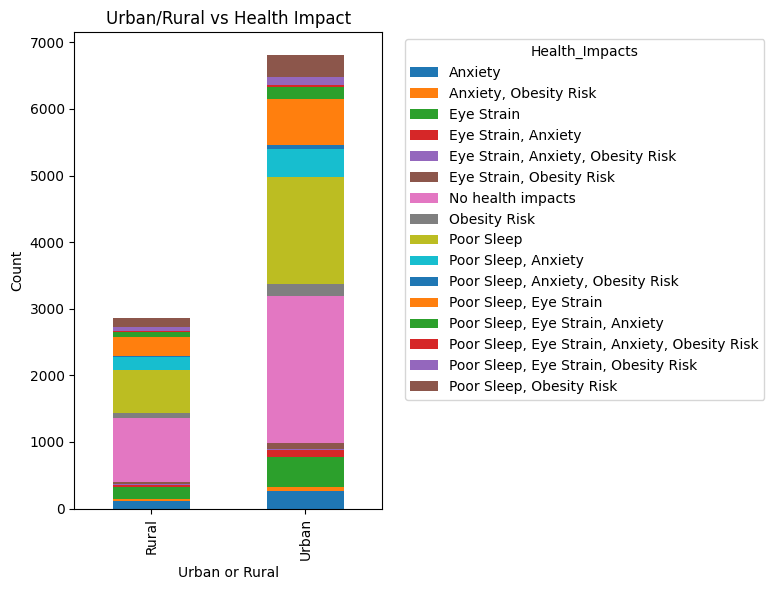

In [66]:
#Urban vs Health Impact
ct2 = pd.crosstab(df['Urban_or_Rural'], df['Health_Impacts'])

ax = ct2.plot(kind='bar', stacked=True, figsize=(8,6))

plt.title('Urban/Rural vs Health Impact')
plt.xlabel('Urban or Rural')
plt.ylabel('Count')

plt.legend(title='Health_Impacts', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
!pip install seaborn

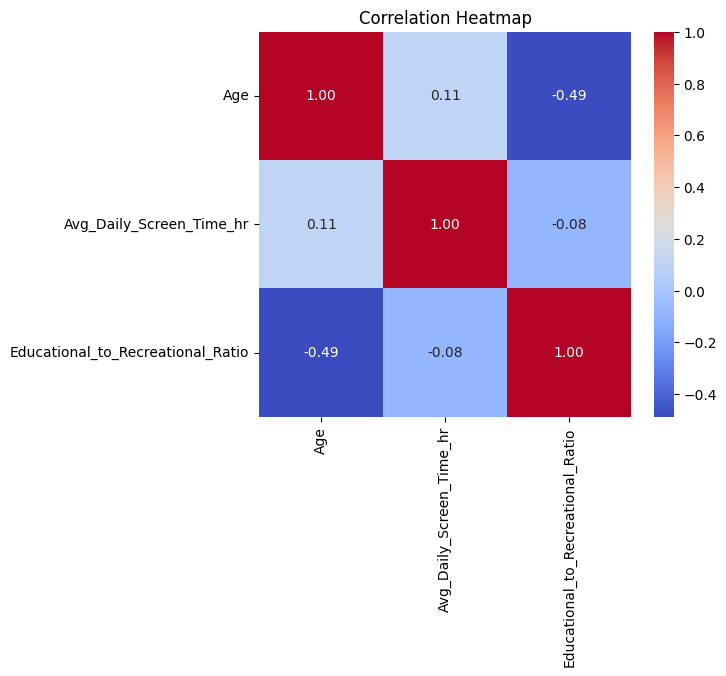

In [68]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['Age',
                  'Avg_Daily_Screen_Time_hr',
                  'Educational_to_Recreational_Ratio']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

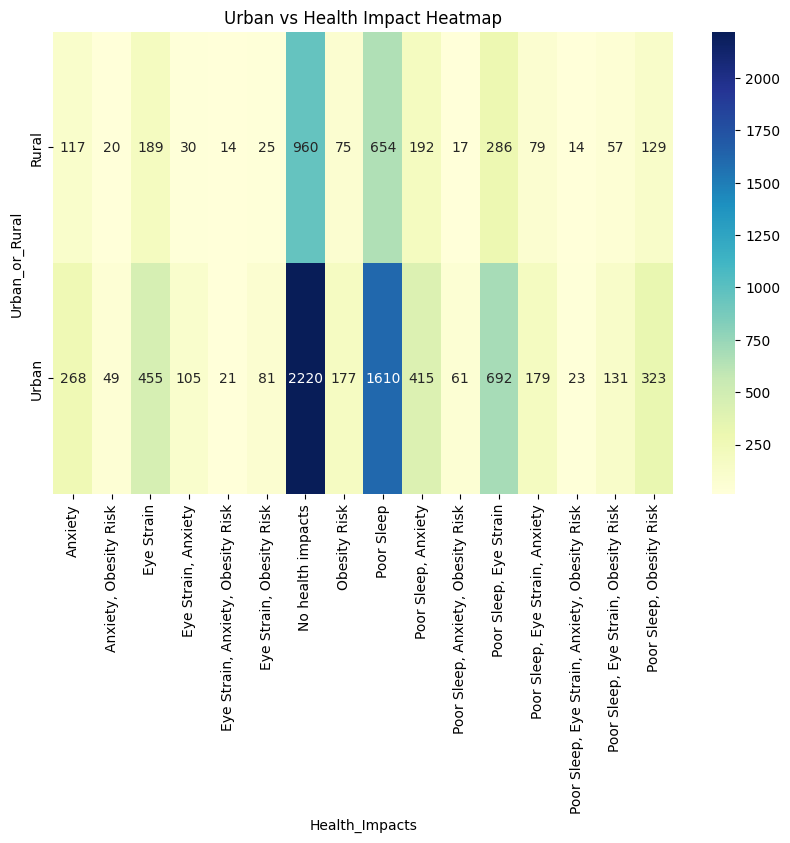

In [69]:
#Categorical vs Categorical Heatmap
ct2 = pd.crosstab(df['Urban_or_Rural'], df['Health_Impacts'])

plt.figure(figsize=(10,6))
sns.heatmap(ct2, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Urban vs Health Impact Heatmap')
plt.show()

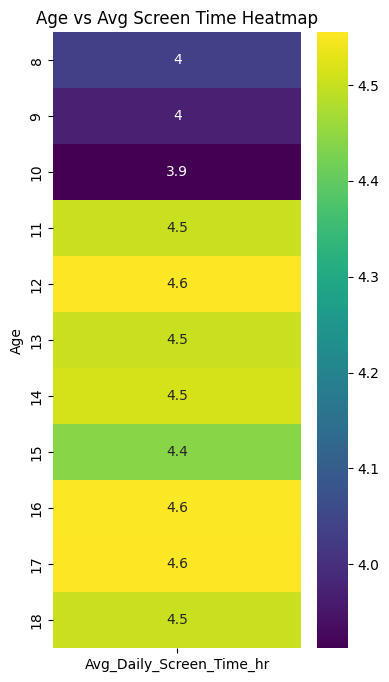

In [70]:
#Age vs Screen Time Heatmap
age_screen = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

pivot_table = age_screen.pivot_table(values='Avg_Daily_Screen_Time_hr',
                                     index='Age')

plt.figure(figsize=(4,8))
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('Age vs Avg Screen Time Heatmap')
plt.show()

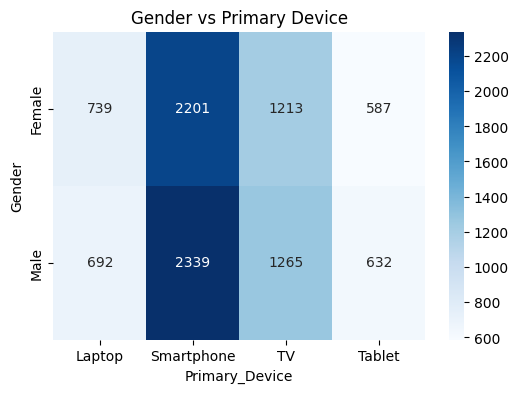

In [71]:
#Gender vs Device Heatmap
ct = pd.crosstab(df['Gender'], df['Primary_Device'])

plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, cmap='Blues', fmt='d')
plt.title('Gender vs Primary Device')
plt.show()